# AI306 Data Mining Project Notebook

## Predicting UK Road Collision Severity Using Classification Models

**Course:** AI306 - Data Mining  
**Academic Year:** 2025-2026  
**Task:** Multi-class classification  
**Target:** `collision_severity`

| Class | Meaning |
|---:|---|
| 1 | Fatal |
| 2 | Serious |
| 3 | Slight |

This notebook uses the full dataset, handles class imbalance, checks leakage and overfitting, and compares several classification models.

In [1]:
# ============================================================
# Download Dataset Automatically
# ============================================================

from pathlib import Path
import urllib.request

# Official UK Department for Transport collision dataset URL
DATA_URL = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-2023.csv"

# Local file name expected by the notebook
DATA_PATH = Path("dft-road-casualty-statistics-collision-2023.csv")

# Download the dataset only if it does not already exist
if DATA_PATH.exists():
    print(f"Dataset already exists: {DATA_PATH}")
else:
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f"Dataset downloaded successfully: {DATA_PATH}")

Dataset downloaded successfully: dft-road-casualty-statistics-collision-2023.csv


In [2]:
import pandas as pd

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(104258, 44)


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2023170L30453,2023,170L30453,456584.0,522423.0,-1.125794,54.593835,17,3,3,...,0,13,2,2,2,E01032560,-1,0,0.014215,0.985785
1,2023111293075,2023,111293075,434218.0,514041.0,-1.472891,54.520515,11,3,1,...,0,0,2,1,2,E01012346,3,1,0.000000,1.000000
2,2023111312748,2023,111312748,430616.0,514267.0,-1.528511,54.522776,11,2,2,...,0,0,1,3,2,E01012319,7,1,1.000000,0.000000
3,2023070702777,2023,070702777,360889.0,389063.0,-2.589645,53.396939,7,3,2,...,0,0,1,1,2,E01012483,-1,0,0.148246,0.851754
4,2023070866538,2023,070866538,360571.0,389398.0,-2.594469,53.399926,7,3,2,...,0,0,1,1,2,E01012454,-1,0,0.138077,0.861923


In [3]:
# ============================================================
# 1. Import Libraries
# ============================================================

from __future__ import annotations

import os
import time
import warnings
from pathlib import Path
from typing import Dict, List

# Hide warning messages to keep notebook output clean
warnings.filterwarnings("ignore")

# Limit low-level thread usage to avoid kernel crashes or slowdowns
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

# Main data libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display tables nicely inside Jupyter
from IPython.display import display

# Scikit-learn preprocessing and modelling tools
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Imbalance handling tools
try:
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("Warning: imbalanced-learn is not installed. Resampling experiments will be skipped.")

In [4]:
# ============================================================
# 2. Global Configuration
# ============================================================

# Fixed random state makes the results reproducible
RANDOM_STATE = 42

# Dataset and target column
TARGET = "collision_severity"
DATA_PATH = "dft-road-casualty-statistics-collision-2023.csv"

# Target class names
SEVERITY_LABELS = {
    1: "Fatal",
    2: "Serious",
    3: "Slight",
}

TARGET_CLASSES = [1, 2, 3]
TARGET_NAMES = [SEVERITY_LABELS[i] for i in TARGET_CLASSES]

# Only chart saving is kept because charts are needed for the report
# Report text files, CSV summaries, JSON summaries, and decision logs are removed
OUTPUT_DIR = Path("outputs")
CHART_DIR = OUTPUT_DIR / "charts"

# Features selected for modelling
FEATURES = [
    "number_of_vehicles",
    "day_of_week",
    "road_type",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "first_road_class",
    "second_road_class",
    "pedestrian_crossing",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "special_conditions_at_site",
    "carriageway_hazards",
    "urban_or_rural_area",
    "trunk_road_flag",
    "month",
    "hour",
    "is_weekend",
    "time_period",
]

# These selected features are treated as numeric
NUMERIC_FEATURES_CANDIDATES = [
    "number_of_vehicles",
    "speed_limit",
    "month",
    "hour",
    "is_weekend",
]

# These columns are excluded because they are IDs, location/admin columns,
# historical duplicate columns, or leakage-risk outcome columns.
EXCLUDE_COLUMNS = [
    "collision_index",
    "collision_ref_no",
    "collision_year",
    "location_easting_osgr",
    "location_northing_osgr",
    "longitude",
    "latitude",
    "police_force",
    "local_authority_district",
    "local_authority_ons_district",
    "local_authority_highway",
    "local_authority_highway_current",
    "first_road_number",
    "second_road_number",
    "junction_detail_historic",
    "pedestrian_crossing_human_control_historic",
    "pedestrian_crossing_physical_facilities_historic",
    "carriageway_hazards_historic",
    "lsoa_of_accident_location",
    "number_of_casualties",
    "enhanced_severity_collision",
    "collision_injury_based",
    "collision_adjusted_severity_serious",
    "collision_adjusted_severity_slight",
]

# These columns are used only in the leakage diagnostic experiment
LEAKAGE_DIAGNOSTIC_COLUMNS = [
    "number_of_casualties",
    "enhanced_severity_collision",
    "collision_injury_based",
    "collision_adjusted_severity_serious",
    "collision_adjusted_severity_slight",
]

In [5]:
# ============================================================
# 3. Helper Functions
# ============================================================

def create_output_folders() -> None:
    """Create folders for chart outputs only."""
    OUTPUT_DIR.mkdir(exist_ok=True)
    CHART_DIR.mkdir(parents=True, exist_ok=True)


def note(message: str) -> None:
    """Print a simple note instead of saving a decision log file."""
    print(f"[Note] {message}")


def safe_slug(text: str) -> str:
    """Convert a model name into a safe filename."""
    return (
        text.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
        .replace("-", "_")
        .replace("(", "")
        .replace(")", "")
    )


def save_plot(path: Path) -> None:
    """Save the current matplotlib figure and display it inside the notebook."""
    plt.tight_layout()

    # Save chart image for the report
    plt.savefig(path, dpi=200, bbox_inches="tight")

    # Display chart in the notebook
    plt.show()

    # Close figure to reduce memory usage
    plt.close()


def make_one_hot_encoder() -> OneHotEncoder:
    """Create OneHotEncoder in a way that works with different scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def find_dataset_path() -> Path:
    """Find the dataset in the current folder or the notebook/script folder."""
    candidates = [
        Path(DATA_PATH),
        Path(__file__).parent / DATA_PATH if "__file__" in globals() else Path(DATA_PATH),
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Backup search if the exact filename is slightly different
    for pattern in [
        "dft-road-casualty-statistics-collision-2023*.csv",
        "*collision*2023*.csv",
    ]:
        matches = sorted(Path.cwd().glob(pattern))
        if matches:
            return matches[0]

    raise FileNotFoundError(
        "Dataset not found. Place dft-road-casualty-statistics-collision-2023.csv "
        "in the same folder as this notebook, or update DATA_PATH."
    )


def severity_name(series: pd.Series) -> pd.Series:
    """Convert severity numbers into readable labels."""
    return series.map(SEVERITY_LABELS).fillna("Unknown")


# Create the output chart folder
create_output_folders()

In [6]:
# ============================================================
# 4. Load Dataset
# ============================================================

def load_dataset() -> pd.DataFrame:
    """Load the collision dataset from CSV."""
    data_path = find_dataset_path()
    df = pd.read_csv(data_path, low_memory=False)

    note(f"Loaded dataset from {data_path} with shape {df.shape}.")

    return df


df_original = load_dataset()

# Preview first rows
df_original.head()

[Note] Loaded dataset from dft-road-casualty-statistics-collision-2023.csv with shape (104258, 44).


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2023170L30453,2023,170L30453,456584.0,522423.0,-1.125794,54.593835,17,3,3,...,0,13,2,2,2,E01032560,-1,0,0.014215,0.985785
1,2023111293075,2023,111293075,434218.0,514041.0,-1.472891,54.520515,11,3,1,...,0,0,2,1,2,E01012346,3,1,0.000000,1.000000
2,2023111312748,2023,111312748,430616.0,514267.0,-1.528511,54.522776,11,2,2,...,0,0,1,3,2,E01012319,7,1,1.000000,0.000000
3,2023070702777,2023,070702777,360889.0,389063.0,-2.589645,53.396939,7,3,2,...,0,0,1,1,2,E01012483,-1,0,0.148246,0.851754
4,2023070866538,2023,070866538,360571.0,389398.0,-2.594469,53.399926,7,3,2,...,0,0,1,1,2,E01012454,-1,0,0.138077,0.861923


In [7]:
# ============================================================
# 5. Dataset Overview
# ============================================================

# Show dataset size
print("Dataset shape:", df_original.shape)

# Show first rows
print("\nFirst 5 rows:")
display(df_original.head())

# Show column data types
print("\nData types:")
dtypes = df_original.dtypes.astype(str).reset_index()
dtypes.columns = ["column", "dtype"]
display(dtypes)

# Show missing values summary
print("\nMissing values:")
missing_all = pd.DataFrame({
    "column": df_original.columns,
    "missing_count": df_original.isna().sum().values,
    "missing_percentage": (df_original.isna().mean().values * 100).round(3),
}).sort_values("missing_count", ascending=False)

display(missing_all.head(15))

Dataset shape: (104258, 44)

First 5 rows:


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2023170L30453,2023,170L30453,456584.0,522423.0,-1.125794,54.593835,17,3,3,...,0,13,2,2,2,E01032560,-1,0,0.014215,0.985785
1,2023111293075,2023,111293075,434218.0,514041.0,-1.472891,54.520515,11,3,1,...,0,0,2,1,2,E01012346,3,1,0.000000,1.000000
2,2023111312748,2023,111312748,430616.0,514267.0,-1.528511,54.522776,11,2,2,...,0,0,1,3,2,E01012319,7,1,1.000000,0.000000
3,2023070702777,2023,070702777,360889.0,389063.0,-2.589645,53.396939,7,3,2,...,0,0,1,1,2,E01012483,-1,0,0.148246,0.851754
4,2023070866538,2023,070866538,360571.0,389398.0,-2.594469,53.399926,7,3,2,...,0,0,1,1,2,E01012454,-1,0,0.138077,0.861923



Data types:


,column,dtype
0,collision_index,str
1,collision_year,int64
2,collision_ref_no,str
3,location_easting_osgr,float64
4,location_northing_osgr,float64
5,longitude,float64
6,latitude,float64
7,police_force,int64
8,collision_severity,int64
9,number_of_vehicles,int64



Missing values:


,column,missing_count,missing_percentage
17,local_authority_highway_current,16,0.015
3,location_easting_osgr,12,0.012
5,longitude,12,0.012
6,latitude,12,0.012
4,location_northing_osgr,12,0.012
2,collision_ref_no,0,0.000
0,collision_index,0,0.000
1,collision_year,0,0.000
8,collision_severity,0,0.000
9,number_of_vehicles,0,0.000


,collision_severity,label,count,percentage
0,1,Fatal,1522,1.460
1,2,Serious,23438,22.481
2,3,Slight,79298,76.059


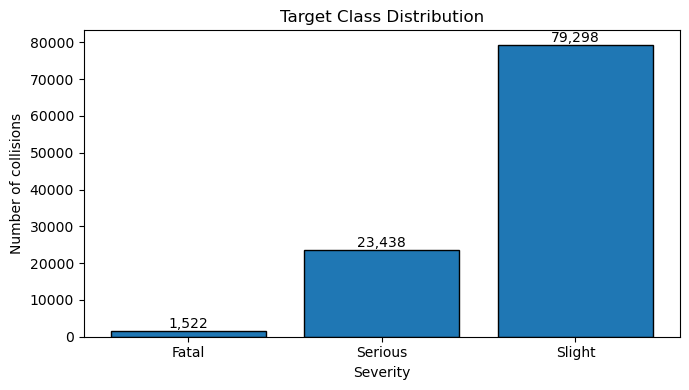

[Note] Target distribution: {1: 1522, 2: 23438, 3: 79298}. This confirms severe class imbalance.


In [8]:
# ============================================================
# 6. Target Variable Analysis
# ============================================================

# Check that target column exists
if TARGET not in df_original.columns:
    raise KeyError(f"Target column {TARGET} was not found.")

# Keep only valid target classes
df = df_original[df_original[TARGET].isin(TARGET_CLASSES)].copy()
y_all = df[TARGET].astype(int)

# Count each severity class
target_counts = y_all.value_counts().sort_index()

# Build target distribution table
target_distribution = pd.DataFrame({
    "collision_severity": target_counts.index,
    "label": [SEVERITY_LABELS[i] for i in target_counts.index],
    "count": target_counts.values,
    "percentage": (target_counts.values / len(y_all) * 100).round(3),
})

display(target_distribution)

# Plot target distribution
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    target_distribution["label"],
    target_distribution["count"],
    edgecolor="black",
)

ax.set_title("Target Class Distribution")
ax.set_xlabel("Severity")
ax.set_ylabel("Number of collisions")

# Add count labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
    )

fig.tight_layout()
fig.savefig(CHART_DIR / "target_distribution.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

note(
    f"Target distribution: {target_counts.to_dict()}. "
    "This confirms severe class imbalance."
)

In [9]:
# ============================================================
# 7. Data Cleaning
# ============================================================

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Keep valid target rows and safely parse date/time columns."""
    df_clean = df[df[TARGET].isin(TARGET_CLASSES)].copy()

    # Parse date
    df_clean["date_parsed"] = pd.to_datetime(
        df_clean["date"],
        errors="coerce",
        dayfirst=True,
    )

    # Parse time
    df_clean["time_parsed"] = pd.to_datetime(
        df_clean["time"].astype(str).str.strip(),
        format="%H:%M",
        errors="coerce",
    )

    # Count invalid dates/times
    invalid_dates = int(df_clean["date_parsed"].isna().sum())
    invalid_times = int(df_clean["time_parsed"].isna().sum())

    note(f"Invalid parsed dates: {invalid_dates}")
    note(f"Invalid parsed times: {invalid_times}")
    note("Leakage-risk columns are excluded from final models.")

    return df_clean


df_clean = clean_data(df_original)

df_clean.head()

[Note] Invalid parsed dates: 0
[Note] Invalid parsed times: 0
[Note] Leakage-risk columns are excluded from final models.


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight,date_parsed,time_parsed
0,2023170L30453,2023,170L30453,456584.0,522423.0,-1.125794,54.593835,17,3,3,...,2,2,2,E01032560,-1,0,0.014215,0.985785,2023-05-21,1900-01-01 18:00:00
1,2023111293075,2023,111293075,434218.0,514041.0,-1.472891,54.520515,11,3,1,...,2,1,2,E01012346,3,1,0.000000,1.000000,2023-03-28,1900-01-01 15:00:00
2,2023111312748,2023,111312748,430616.0,514267.0,-1.528511,54.522776,11,2,2,...,1,3,2,E01012319,7,1,1.000000,0.000000,2023-05-21,1900-01-01 23:30:00
3,2023070702777,2023,070702777,360889.0,389063.0,-2.589645,53.396939,7,3,2,...,1,1,2,E01012483,-1,0,0.148246,0.851754,2023-08-02,1900-01-01 13:45:00
4,2023070866538,2023,070866538,360571.0,389398.0,-2.594469,53.399926,7,3,2,...,1,1,2,E01012454,-1,0,0.138077,0.861923,2023-09-11,1900-01-01 06:46:00


In [10]:
# ============================================================
# 8. Feature Engineering
# ============================================================

def hour_to_period(hour_value):
    """Convert hour into a simple period of the day."""
    if pd.isna(hour_value):
        return "Unknown"

    hour = int(hour_value)

    if 5 <= hour <= 11:
        return "Morning"
    if 12 <= hour <= 16:
        return "Afternoon"
    if 17 <= hour <= 20:
        return "Evening"

    return "Night"


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create month, hour, weekend, and time-period features."""
    df_fe = df.copy()

    # Extract month and hour
    df_fe["month"] = df_fe["date_parsed"].dt.month
    df_fe["hour"] = df_fe["time_parsed"].dt.hour

    # Convert day_of_week to numeric
    day_numeric = pd.to_numeric(df_fe["day_of_week"], errors="coerce")

    # Mark weekend as 1 and weekday as 0
    df_fe["is_weekend"] = np.where(day_numeric.isin([1, 7]), 1, 0)
    df_fe.loc[day_numeric.isna(), "is_weekend"] = np.nan

    # Create time period category
    df_fe["time_period"] = df_fe["hour"].apply(hour_to_period)

    note("Created month, hour, is_weekend, and time_period features.")

    return df_fe


df_engineered = engineer_features(df_clean)

df_engineered[["date", "time", "month", "hour", "is_weekend", "time_period"]].head()

[Note] Created month, hour, is_weekend, and time_period features.


,date,time,month,hour,is_weekend,time_period
0,21/05/2023,18:00,5,18,1.0,Evening
1,28/03/2023,15:00,3,15,0.0,Afternoon
2,21/05/2023,23:30,5,23,1.0,Night
3,02/08/2023,13:45,8,13,0.0,Afternoon
4,11/09/2023,06:46,9,6,0.0,Morning


In [11]:
# ============================================================
# 9. Feature Selection
# ============================================================

def select_and_prepare_features(df: pd.DataFrame):
    """Select final model features and prepare unknown/missing values."""
    # Keep features that exist in the dataset
    selected_features = [feature for feature in FEATURES if feature in df.columns]

    # Show any missing selected features
    missing_selected = [feature for feature in FEATURES if feature not in df.columns]
    if missing_selected:
        note(f"Missing selected features removed: {missing_selected}")

    # Remove any excluded columns if they accidentally appear
    accidental_excluded = [feature for feature in selected_features if feature in EXCLUDE_COLUMNS]
    if accidental_excluded:
        selected_features = [
            feature for feature in selected_features
            if feature not in accidental_excluded
        ]
        note(f"Removed excluded features: {accidental_excluded}")

    # Split features into numeric and categorical
    numeric_features = [
        feature for feature in NUMERIC_FEATURES_CANDIDATES
        if feature in selected_features
    ]

    categorical_features = [
        feature for feature in selected_features
        if feature not in numeric_features
    ]

    X = df[selected_features].copy()
    y = df[TARGET].astype(int).copy()

    # Build a missing/unknown summary for selected features
    missing_summary = []

    for feature in selected_features:
        if pd.api.types.is_numeric_dtype(df[feature]):
            minus_one_count = int((df[feature] == -1).sum())
        else:
            minus_one_count = int((df[feature].astype(str) == "-1").sum())

        missing_summary.append({
            "feature": feature,
            "missing_count": int(df[feature].isna().sum()),
            "minus_one_count": minus_one_count,
        })

    missing_summary_df = pd.DataFrame(missing_summary)

    print("Missing and coded unknown summary:")
    display(missing_summary_df)

    # Treat categorical -1 values as Unknown
    for feature in categorical_features:
        X[feature] = X[feature].replace(-1, "Unknown").replace("-1", "Unknown")
        X[feature] = X[feature].fillna("Unknown").astype(str)

    # Treat numeric -1 values as missing
    for feature in numeric_features:
        X[feature] = pd.to_numeric(X[feature], errors="coerce")
        X.loc[X[feature] == -1, feature] = np.nan

    note(f"Selected features: {selected_features}")
    note(f"Numeric features: {numeric_features}")
    note(f"Categorical features: {categorical_features}")

    return X, y, selected_features, numeric_features, categorical_features, missing_summary_df


X, y, selected_features, numeric_features, categorical_features, missing_summary_df = select_and_prepare_features(df_engineered)

print("X shape:", X.shape)
print("y shape:", y.shape)

Missing and coded unknown summary:


,feature,missing_count,minus_one_count
0,number_of_vehicles,0,0
1,day_of_week,0,0
2,road_type,0,0
3,speed_limit,0,0
4,junction_detail,0,2398
5,junction_control,0,43795
6,first_road_class,0,0
7,second_road_class,0,84
8,pedestrian_crossing,0,2768
9,light_conditions,0,0


[Note] Selected features: ['number_of_vehicles', 'day_of_week', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'first_road_class', 'second_road_class', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'trunk_road_flag', 'month', 'hour', 'is_weekend', 'time_period']
[Note] Numeric features: ['number_of_vehicles', 'speed_limit', 'month', 'hour', 'is_weekend']
[Note] Categorical features: ['day_of_week', 'road_type', 'junction_detail', 'junction_control', 'first_road_class', 'second_road_class', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'trunk_road_flag', 'time_period']
X shape: (104258, 20)
y shape: (104258,)


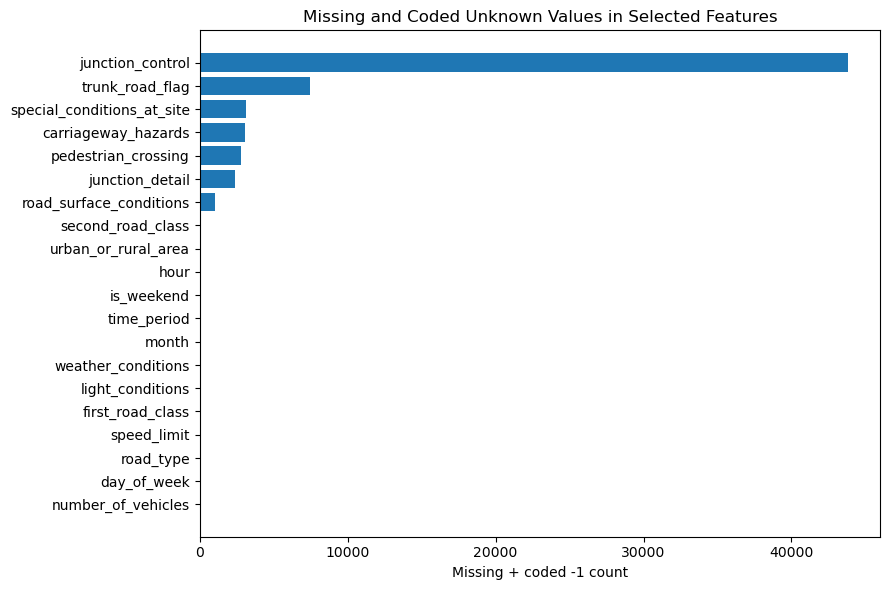

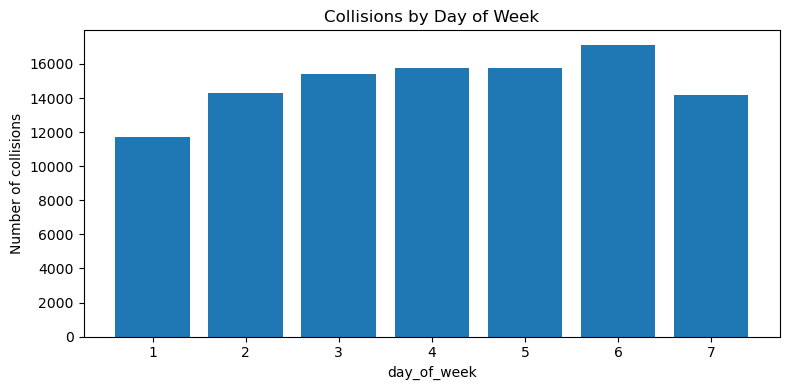

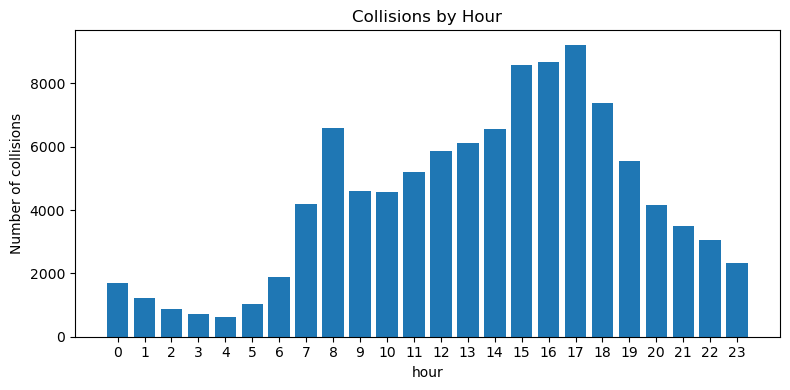

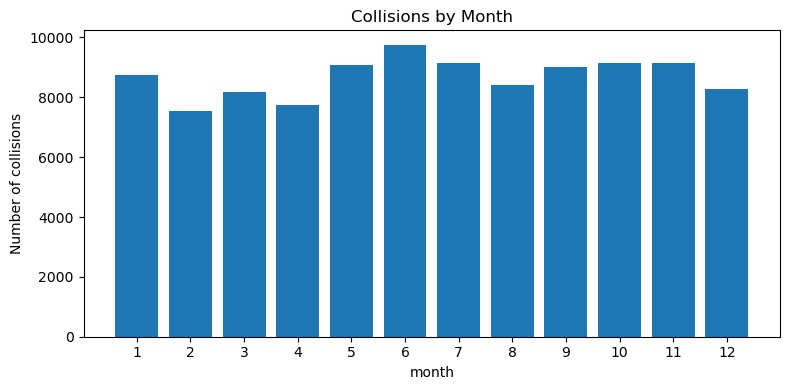

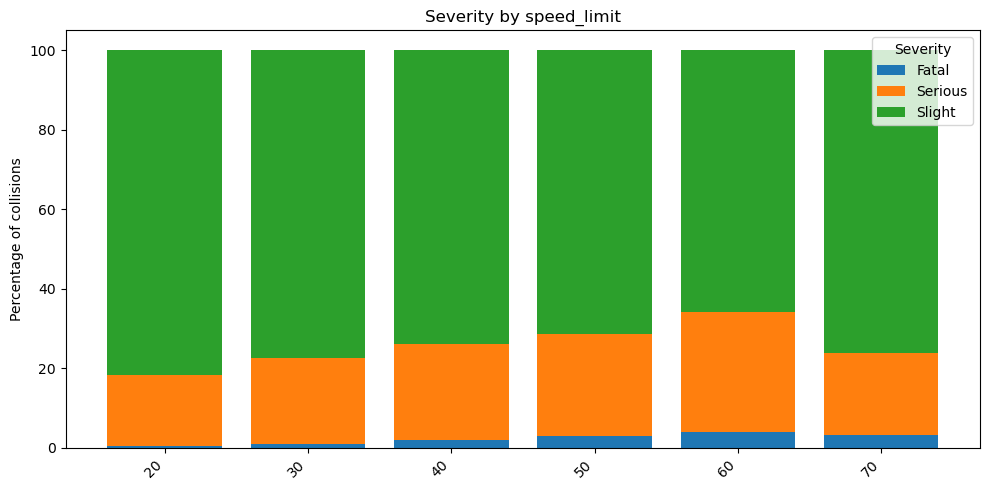

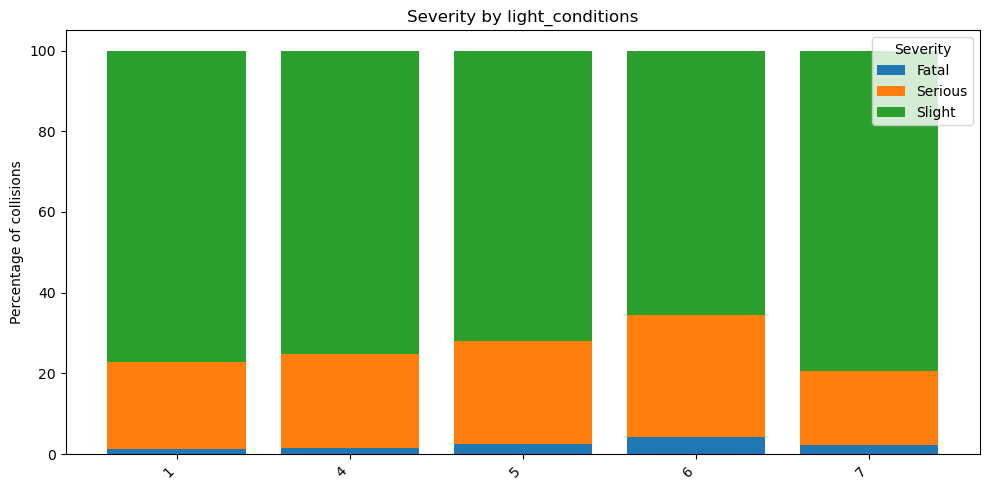

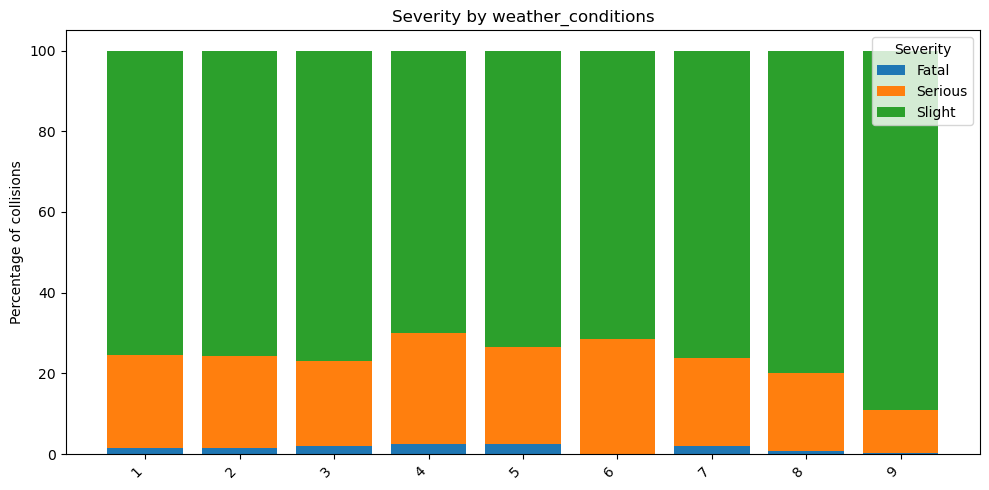

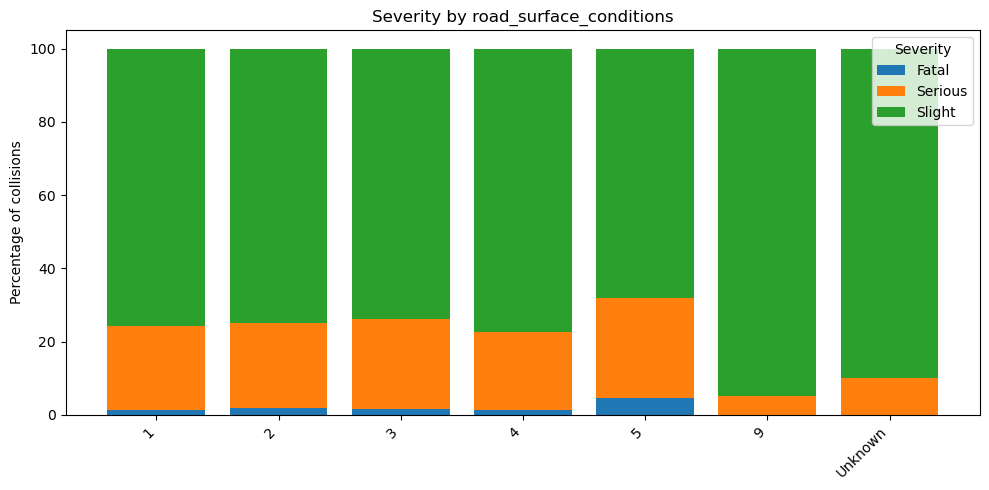

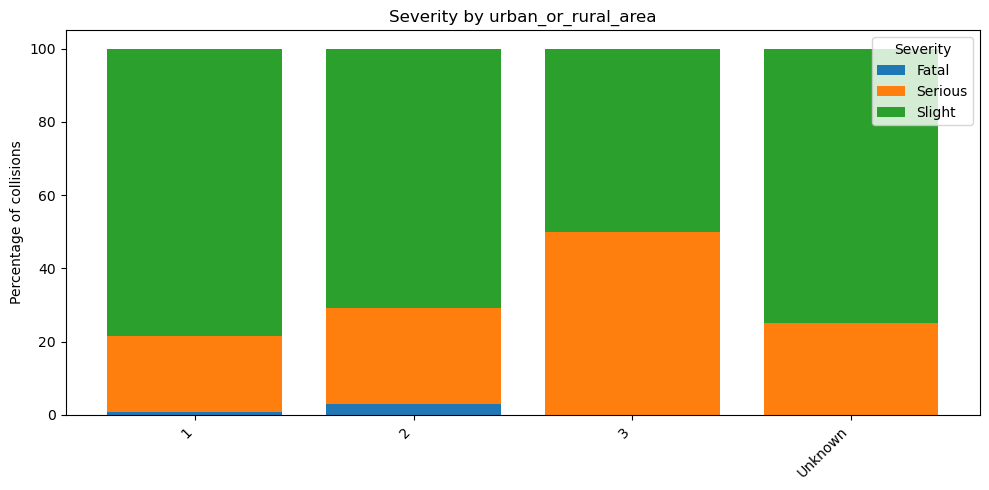

In [12]:
# ============================================================
# 10. Exploratory Data Analysis
# ============================================================

def plot_missing_values_summary(missing_summary_df: pd.DataFrame):
    """Plot missing and coded unknown values in selected features."""
    temp = missing_summary_df.copy()
    temp["total_missing_or_unknown"] = temp["missing_count"] + temp["minus_one_count"]
    temp = temp.sort_values("total_missing_or_unknown")

    plt.figure(figsize=(9, 6))
    plt.barh(temp["feature"], temp["total_missing_or_unknown"])
    plt.title("Missing and Coded Unknown Values in Selected Features")
    plt.xlabel("Missing + coded -1 count")
    save_plot(CHART_DIR / "missing_values_summary.png")


def plot_count_feature(df: pd.DataFrame, feature: str, title: str, output_name: str):
    """Plot basic count distribution for one feature."""
    counts = df[feature].value_counts(dropna=False).sort_index()

    plt.figure(figsize=(8, 4))
    plt.bar([str(index) for index in counts.index], counts.values)
    plt.title(title)
    plt.xlabel(feature)
    plt.ylabel("Number of collisions")
    save_plot(CHART_DIR / output_name)


def plot_severity_by_feature(df: pd.DataFrame, feature: str, output_name: str):
    """Plot severity percentage by selected feature."""
    temp = df[[feature, TARGET]].copy()

    # Prepare unknown values for plotting
    temp[feature] = (
        temp[feature]
        .replace(-1, "Unknown")
        .replace("-1", "Unknown")
        .fillna("Unknown")
        .astype(str)
    )

    # Keep top categories to avoid crowded plots
    top_categories = temp[feature].value_counts().head(12).index
    temp.loc[~temp[feature].isin(top_categories), feature] = "Other"

    # Build normalized crosstab
    table = pd.crosstab(temp[feature], temp[TARGET], normalize="index") * 100
    table = table.reindex(columns=TARGET_CLASSES, fill_value=0)

    x = np.arange(len(table.index))
    bottom = np.zeros(len(table.index))

    plt.figure(figsize=(10, 5))

    for class_id, class_name in zip(TARGET_CLASSES, TARGET_NAMES):
        values = table[class_id].values
        plt.bar(x, values, bottom=bottom, label=class_name)
        bottom += values

    plt.xticks(x, table.index, rotation=45, ha="right")
    plt.title(f"Severity by {feature}")
    plt.ylabel("Percentage of collisions")
    plt.legend(title="Severity")
    save_plot(CHART_DIR / output_name)


# Plot EDA charts
plot_missing_values_summary(missing_summary_df)

plot_count_feature(df_engineered, "day_of_week", "Collisions by Day of Week", "collisions_by_day_of_week.png")
plot_count_feature(df_engineered, "hour", "Collisions by Hour", "collisions_by_hour.png")
plot_count_feature(df_engineered, "month", "Collisions by Month", "collisions_by_month.png")

for feature in [
    "speed_limit",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
]:
    plot_severity_by_feature(
        df_engineered,
        feature,
        f"severity_by_{feature}.png",
    )

In [13]:
# ============================================================
# 11. Preprocessing Pipeline
# ============================================================

def build_preprocessor(
    numeric_features: List[str],
    categorical_features: List[str],
) -> ColumnTransformer:
    """Build preprocessing steps for numeric and categorical features."""
    # Numeric columns: fill missing values, then scale
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    # Categorical columns: fill missing values, then one-hot encode
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_one_hot_encoder()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )

    return preprocessor


preprocessor = build_preprocessor(numeric_features, categorical_features)

note("Preprocessing pipeline created.")

[Note] Preprocessing pipeline created.


In [14]:
# ============================================================
# 12. Train-Test Split
# ============================================================

# Stratified split keeps the class distribution similar in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target distribution:")
display(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
display(y_test.value_counts().sort_index())

# Fit preprocessing only on training data to avoid leakage
start_time = time.time()

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

transform_seconds = time.time() - start_time

# Store transformed feature names for feature importance later
feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in preprocessor.get_feature_names_out()
]

print("Transformed training shape:", X_train_transformed.shape)
print("Transformed test shape:", X_test_transformed.shape)
print(f"Preprocessing time: {transform_seconds:.2f} seconds")

Training rows: 83406
Testing rows: 20852

Training target distribution:


collision_severity
1     1218
2    18750
3    63438
Name: count, dtype: int64


Testing target distribution:


collision_severity
1      304
2     4688
3    15860
Name: count, dtype: int64

Transformed training shape: (83406, 111)
Transformed test shape: (20852, 111)
Preprocessing time: 1.25 seconds


In [15]:
# ============================================================
# 13. Metric and Confusion Matrix Functions
# ============================================================

def compute_metrics(y_true, y_pred) -> Dict[str, float]:
    """Compute overall, macro, weighted, and per-class metrics."""
    accuracy = accuracy_score(y_true, y_pred)

    # Macro metrics treat all classes equally
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=TARGET_CLASSES,
        average="macro",
        zero_division=0,
    )

    # Weighted metrics account for class size
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=TARGET_CLASSES,
        average="weighted",
        zero_division=0,
    )

    # Per-class metrics
    per_precision, per_recall, per_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=TARGET_CLASSES,
        average=None,
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "fatal_precision": per_precision[0],
        "fatal_recall": per_recall[0],
        "fatal_f1": per_f1[0],
        "serious_precision": per_precision[1],
        "serious_recall": per_recall[1],
        "serious_f1": per_f1[1],
        "slight_precision": per_precision[2],
        "slight_recall": per_recall[2],
        "slight_f1": per_f1[2],
    }


def plot_confusion_matrix(model_name: str, y_true, y_pred) -> None:
    """
    Plot and save confusion matrix only.
    No report text files are created.
    """
    cm = confusion_matrix(y_true, y_pred, labels=TARGET_CLASSES)

    cm_df = pd.DataFrame(
        cm,
        index=TARGET_NAMES,
        columns=TARGET_NAMES,
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted severity")
    plt.ylabel("Actual severity")

    filename = f"confusion_matrix_{safe_slug(model_name)}.png"
    save_plot(CHART_DIR / filename)

Running imbalance method: No imbalance handling
Running imbalance method: Class weighted
Running imbalance method: Random undersampling
Running imbalance method: Random oversampling
Running imbalance method: SMOTE


,method,accuracy,macro_f1,weighted_f1,fatal_recall,serious_recall,slight_recall,resampled_rows
4,SMOTE,0.661184,0.372703,0.663040,0.164474,0.228029,0.798739,190314
3,Random oversampling,0.546518,0.358746,0.599534,0.305921,0.386305,0.598487,190314
1,Class weighted,0.508680,0.344203,0.572466,0.398026,0.375213,0.550252,83406
0,No imbalance handling,0.755995,0.320959,0.677170,0.000000,0.059087,0.976482,83406
2,Random undersampling,0.463840,0.319376,0.536329,0.506579,0.321459,0.505107,3654


,method,class_1_count,class_2_count,class_3_count
0,No imbalance handling,1218,18750,63438
1,Class weighted,1218,18750,63438
2,Random undersampling,1218,1218,1218
3,Random oversampling,63438,63438,63438
4,SMOTE,63438,63438,63438


Best imbalance method by Macro F1: SMOTE


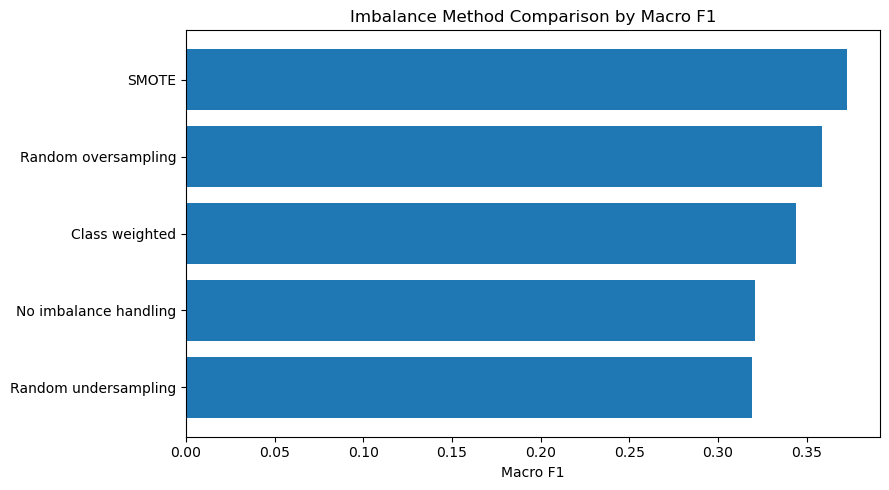

In [16]:
# ============================================================
# 14. Class Imbalance Handling
# ============================================================

if not IMBLEARN_AVAILABLE:
    raise ImportError(
        "Install imbalanced-learn to run RandomOverSampler, RandomUnderSampler, and SMOTE."
    )

# Regularized Decision Tree is used to compare imbalance methods fairly
base_tree_params = dict(
    random_state=RANDOM_STATE,
    max_depth=14,
    min_samples_leaf=20,
)

imbalance_setups = [
    ("No imbalance handling", None, DecisionTreeClassifier(**base_tree_params)),
    ("Class weighted", None, DecisionTreeClassifier(class_weight="balanced", **base_tree_params)),
    ("Random undersampling", RandomUnderSampler(random_state=RANDOM_STATE), DecisionTreeClassifier(**base_tree_params)),
    ("Random oversampling", RandomOverSampler(random_state=RANDOM_STATE), DecisionTreeClassifier(**base_tree_params)),
    ("SMOTE", SMOTE(random_state=RANDOM_STATE, k_neighbors=5), DecisionTreeClassifier(**base_tree_params)),
]

imbalance_rows = []
resampled_class_counts = []

for method_name, sampler, model in imbalance_setups:
    print(f"Running imbalance method: {method_name}")

    # Resample training data only
    if sampler is None:
        X_fit, y_fit = X_train_transformed, y_train
    else:
        X_fit, y_fit = sampler.fit_resample(X_train_transformed, y_train)

    # Save resampled class counts in a table
    class_counts = pd.Series(y_fit).value_counts().sort_index().to_dict()

    resampled_class_counts.append({
        "method": method_name,
        "class_1_count": class_counts.get(1, 0),
        "class_2_count": class_counts.get(2, 0),
        "class_3_count": class_counts.get(3, 0),
    })

    # Train model
    start_time = time.time()
    model.fit(X_fit, y_fit)
    train_seconds = time.time() - start_time

    # Predict test set
    y_pred = model.predict(X_test_transformed)

    # Compute metrics
    row = compute_metrics(y_test, y_pred)
    row.update({
        "method": method_name,
        "train_seconds": train_seconds,
        "resampled_rows": len(y_fit),
    })

    imbalance_rows.append(row)

# Results table for imbalance methods
imbalance_comparison = pd.DataFrame(imbalance_rows).sort_values(
    "macro_f1",
    ascending=False,
)

resampled_class_counts_df = pd.DataFrame(resampled_class_counts)

display(
    imbalance_comparison[
        [
            "method",
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "fatal_recall",
            "serious_recall",
            "slight_recall",
            "resampled_rows",
        ]
    ]
)

display(resampled_class_counts_df)

best_imbalance_method = imbalance_comparison.iloc[0]["method"]

print("Best imbalance method by Macro F1:", best_imbalance_method)

# Chart for imbalance comparison
plt.figure(figsize=(9, 5))
plot_df = imbalance_comparison.sort_values("macro_f1")
plt.barh(plot_df["method"], plot_df["macro_f1"])
plt.title("Imbalance Method Comparison by Macro F1")
plt.xlabel("Macro F1")
save_plot(CHART_DIR / "imbalance_method_macro_f1.png")

SMOTE training data shape: (190314, 111), time: 3.32 seconds
Training Majority Baseline...


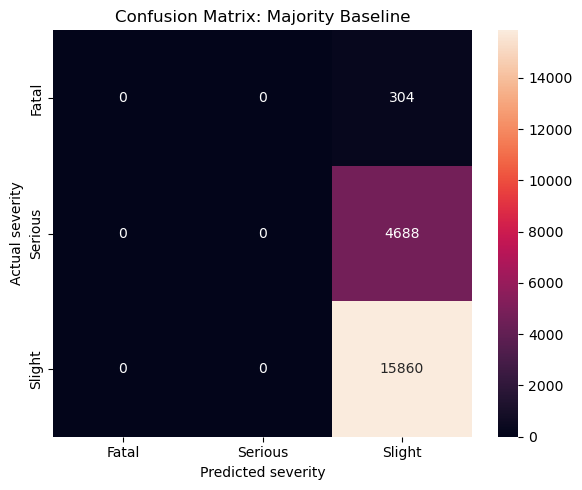

Majority Baseline: Macro F1=0.2880, Fatal Recall=0.0000, Serious Recall=0.0000
Training Logistic Regression Class Weighted...


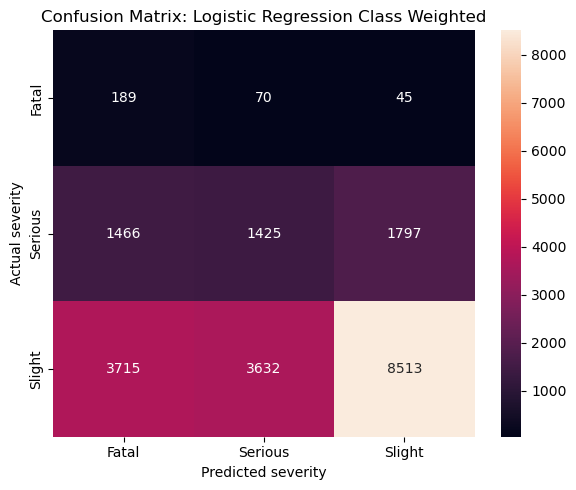

Logistic Regression Class Weighted: Macro F1=0.3355, Fatal Recall=0.6217, Serious Recall=0.3040
Training Decision Tree SMOTE Regularized...


In [ ]:
# ============================================================
# 15. Final Model Training
# ============================================================

# Create SMOTE training data for the final Decision Tree model
start_time = time.time()

X_train_smote, y_train_smote = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=5,
).fit_resample(
    X_train_transformed,
    y_train,
)

print(
    f"SMOTE training data shape: {X_train_smote.shape}, "
    f"time: {time.time() - start_time:.2f} seconds"
)

# Final models to compare
final_model_setups = [
    (
        "Majority Baseline",
        DummyClassifier(strategy="most_frequent"),
        X_train_transformed,
        y_train,
        None,
    ),
    (
        "Logistic Regression Class Weighted",
        LogisticRegression(
            max_iter=100,
            tol=1e-2,
            solver="lbfgs",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        X_train_transformed,
        y_train,
        None,
    ),
    (
        "Decision Tree SMOTE Regularized",
        DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            max_depth=14,
            min_samples_leaf=20,
        ),
        X_train_smote,
        y_train_smote,
        None,
    ),
    (
        "Random Forest Class Weighted Regularized",
        RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            max_depth=16,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced_subsample",
        ),
        X_train_transformed,
        y_train,
        None,
    ),
    (
        "Gradient Boosting Sample Weighted",
        GradientBoostingClassifier(
            random_state=RANDOM_STATE,
            n_estimators=100,
            learning_rate=0.05,
            max_depth=2,
            subsample=0.80,
        ),
        X_train_transformed,
        y_train,
        compute_sample_weight(class_weight="balanced", y=y_train),
    ),
]

trained_models = {}
model_rows = []

for model_name, model, X_fit, y_fit, sample_weight in final_model_setups:
    print(f"Training {model_name}...")

    start_time = time.time()

    # Some models use sample weights, others do not
    if sample_weight is None:
        model.fit(X_fit, y_fit)
    else:
        model.fit(X_fit, y_fit, sample_weight=sample_weight)

    train_seconds = time.time() - start_time

    # Store trained model
    trained_models[model_name] = model

    # Predict test set
    y_pred = model.predict(X_test_transformed)

    # Compute and store metrics
    row = compute_metrics(y_test, y_pred)
    row.update({
        "model": model_name,
        "train_seconds": train_seconds,
    })

    model_rows.append(row)

    # Plot confusion matrix for each model
    plot_confusion_matrix(model_name, y_test, y_pred)

    print(
        f"{model_name}: "
        f"Macro F1={row['macro_f1']:.4f}, "
        f"Fatal Recall={row['fatal_recall']:.4f}, "
        f"Serious Recall={row['serious_recall']:.4f}"
    )

In [ ]:
# ============================================================
# 16. Model Evaluation
# ============================================================

# Compare final models using Macro F1
model_comparison = pd.DataFrame(model_rows).sort_values(
    "macro_f1",
    ascending=False,
)

display(
    model_comparison[
        [
            "model",
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "fatal_recall",
            "serious_recall",
            "slight_recall",
            "train_seconds",
        ]
    ]
)

best_model_name = model_comparison.iloc[0]["model"]
best_model_macro_f1 = model_comparison.iloc[0]["macro_f1"]

print("Best final model by Macro F1:", best_model_name)
print(f"Best final Macro F1: {best_model_macro_f1:.4f}")

In [ ]:
# ============================================================
# 17. Final Model Comparison Chart
# ============================================================

plt.figure(figsize=(9, 5))

plot_df = model_comparison.sort_values("macro_f1")

plt.barh(plot_df["model"], plot_df["macro_f1"])
plt.title("Final Model Comparison by Macro F1")
plt.xlabel("Macro F1")

save_plot(CHART_DIR / "model_comparison_macro_f1.png")

In [ ]:
# ============================================================
# 18. Feature Importance
# ============================================================

# Use Random Forest feature importances
rf_model = trained_models["Random Forest Class Weighted Regularized"]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 20 Random Forest feature importances:")
display(feature_importance.head(20))

# Plot top 25 features
plt.figure(figsize=(9, 8))

top_features = feature_importance.head(25).sort_values("importance")

plt.barh(top_features["feature"], top_features["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

save_plot(CHART_DIR / "feature_importance_random_forest.png")

In [ ]:
# ============================================================
# 19. Overfitting Check
# ============================================================

# Compare training vs testing performance to check overfitting
overfitting_rows = []

for model_name, model in trained_models.items():
    train_pred = model.predict(X_train_transformed)
    test_pred = model.predict(X_test_transformed)

    train_metrics = compute_metrics(y_train, train_pred)
    test_metrics = compute_metrics(y_test, test_pred)

    overfitting_rows.append({
        "model": model_name,
        "train_macro_f1": train_metrics["macro_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "macro_f1_gap": train_metrics["macro_f1"] - test_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "weighted_f1_gap": train_metrics["weighted_f1"] - test_metrics["weighted_f1"],
    })

overfitting_diagnostics = pd.DataFrame(overfitting_rows).sort_values(
    "macro_f1_gap",
    ascending=False,
)

display(overfitting_diagnostics)

largest_gap = overfitting_diagnostics.iloc[0]

print(
    f"Largest overfitting gap: {largest_gap['model']} "
    f"with Macro F1 gap={largest_gap['macro_f1_gap']:.4f}"
)

In [ ]:
# ============================================================
# 20. Leakage Diagnostic
# ============================================================

# This experiment intentionally includes leakage-risk columns
# to prove why they should not be used in the final model
leakage_columns_present = [
    column for column in LEAKAGE_DIAGNOSTIC_COLUMNS
    if column in df_engineered.columns
]

if leakage_columns_present:
    X_leak = df_engineered[selected_features + leakage_columns_present].copy()

    # Prepare categorical features
    for feature in categorical_features:
        X_leak[feature] = (
            X_leak[feature]
            .replace(-1, "Unknown")
            .replace("-1", "Unknown")
            .fillna("Unknown")
            .astype(str)
        )

    leakage_numeric_features = numeric_features + leakage_columns_present

    leakage_categorical_features = [
        feature for feature in X_leak.columns
        if feature not in leakage_numeric_features
    ]

    # Prepare numeric features
    for feature in leakage_numeric_features:
        X_leak[feature] = pd.to_numeric(X_leak[feature], errors="coerce")
        X_leak.loc[X_leak[feature] == -1, feature] = np.nan

    # Train-test split for leakage diagnostic
    X_leak_train, X_leak_test, y_leak_train, y_leak_test = train_test_split(
        X_leak,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    leakage_preprocessor = build_preprocessor(
        leakage_numeric_features,
        leakage_categorical_features,
    )

    X_leak_train_transformed = leakage_preprocessor.fit_transform(X_leak_train)
    X_leak_test_transformed = leakage_preprocessor.transform(X_leak_test)

    # Train simple Decision Tree with leakage columns included
    leakage_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
    leakage_model.fit(X_leak_train_transformed, y_leak_train)

    train_leak_pred = leakage_model.predict(X_leak_train_transformed)
    test_leak_pred = leakage_model.predict(X_leak_test_transformed)

    train_leak_metrics = compute_metrics(y_leak_train, train_leak_pred)
    test_leak_metrics = compute_metrics(y_leak_test, test_leak_pred)

    leakage_diagnostic = pd.DataFrame([{
        "experiment": "Diagnostic model with leakage columns included",
        "leakage_columns": ", ".join(leakage_columns_present),
        "train_accuracy": train_leak_metrics["accuracy"],
        "test_accuracy": test_leak_metrics["accuracy"],
        "train_macro_f1": train_leak_metrics["macro_f1"],
        "test_macro_f1": test_leak_metrics["macro_f1"],
    }])

    display(leakage_diagnostic)

    print(
        "Leakage diagnostic shows unrealistically high performance when "
        "outcome-related columns are included."
    )

else:
    print("No leakage diagnostic columns were found in this dataset.")

In [ ]:
# ============================================================
# 21. Final Code Summary
# ============================================================

# Display final summary only.
# Nothing is saved as JSON or report files.
summary = {
    "rows": int(len(df_engineered)),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "selected_features": selected_features,
    "best_imbalance_method_by_macro_f1": str(best_imbalance_method),
    "best_model_by_macro_f1": str(best_model_name),
    "best_model_macro_f1": float(best_model_macro_f1),
    "target_distribution": {
        int(k): int(v)
        for k, v in y.value_counts().sort_index().items()
    },
}

display(summary)

print("Project code completed successfully.")
print("Charts saved in:", CHART_DIR.resolve())